In [2]:
#1 imports + load datasets
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

data_path = "../data/LandsatKelpBiomass_2025_Q3_v2_withmetadata.nc"

# NOTE: xarray open is optional now (netCDF4 does the real work fast).
# Keeping this only if you like inspecting ds.
ds = xr.open_dataset(data_path, engine="netcdf4")  # IMPORTANT: force engine
print(ds)


<xarray.Dataset> Size: 4GB
Dimensions:     (time: 167, station: 594107)
Coordinates:
  * time        (time) datetime64[ns] 1kB 1984-02-15 1984-05-15 ... 2025-08-15
Dimensions without coordinates: station
Data variables: (12/13)
    latitude    (station) float64 5MB ...
    longitude   (station) float64 5MB ...
    year        (time) int32 668B ...
    quarter     (time) int16 334B ...
    biomass     (time, station) float64 794MB ...
    biomass_se  (time, station) float64 794MB ...
    ...          ...
    area_se     (time, station) float64 794MB ...
    passes      (time, station) int16 198MB ...
    passes5     (time, station) int16 198MB ...
    passes7     (time, station) int16 198MB ...
    passes8     (time, station) int16 198MB ...
    passes6     (time, station) int16 198MB ...
Attributes: (12/50)
    title:                           SBC LTER: Time series of quarterly NetCD...
    summary:                         Wet biomass (kg) of giant kelp (Macrocys...
    keywords:      

In [3]:
#2 imports + load datasets
lat_min, lat_max = 33.8, 34.8
lon_min, lon_max = -120.8, -119.0

lat = ds["latitude"].values
lon = ds["longitude"].values

mask_np = (lat >= lat_min) & (lat <= lat_max) & (lon >= lon_min) & (lon <= lon_max)
stations_all = np.flatnonzero(mask_np)

print("Stations in region:", stations_all.size)
print("Example station ids:", stations_all[:10])
print(ds)


Stations in region: 114834
Example station ids: [160882 161406 161433 163553 163554 163555 163556 163558 163559 163560]
<xarray.Dataset> Size: 4GB
Dimensions:     (time: 167, station: 594107)
Coordinates:
  * time        (time) datetime64[ns] 1kB 1984-02-15 1984-05-15 ... 2025-08-15
Dimensions without coordinates: station
Data variables: (12/13)
    latitude    (station) float64 5MB 42.8 42.8 42.78 ... 27.01 27.01 27.01
    longitude   (station) float64 5MB -124.6 -124.6 -124.6 ... -114.0 -114.0
    year        (time) int32 668B ...
    quarter     (time) int16 334B ...
    biomass     (time, station) float64 794MB ...
    biomass_se  (time, station) float64 794MB ...
    ...          ...
    area_se     (time, station) float64 794MB ...
    passes      (time, station) int16 198MB ...
    passes5     (time, station) int16 198MB ...
    passes7     (time, station) int16 198MB ...
    passes8     (time, station) int16 198MB ...
    passes6     (time, station) int16 198MB ...
Attributes: 

In [4]:
#3 DEV: choose FAST stations (contiguous block)
# Better dev: random sample across bbox (not "first 5000" which can be spatially biased)
N = 5000
seed = 0

rng = np.random.default_rng(seed)
stations_dev = rng.choice(stations_all, size=min(N, stations_all.size), replace=False)

print("DEV stations:", len(stations_dev))
print("Example dev ids:", stations_dev[:10])


DEV stations: 5000
Example dev ids: [173465 193415 221450 255344 245320 240502 213826 236845 259661 207405]


In [5]:
#4 FAST bbox extraction (netCDF4 run-slices)
import numpy as np
import pandas as pd
from netCDF4 import Dataset, num2date
import time

data_path = "../data/LandsatKelpBiomass_2025_Q3_v2_withmetadata.nc"

# --- your bbox ---
lat_min, lat_max = 33.8, 34.8
lon_min, lon_max = -120.8, -119.0

# --- tuning ---
RUN_MODE_MAX_RUNS = 5000      # if bbox indices form <= this many contiguous runs, use run-mode
BLOCK_SIZE = 100_000          # fallback block scan size (stations)
PRINT_EVERY = 50              # progress prints

t0 = time.time()

with Dataset(data_path, "r") as nc:
    # 1) read coords (fast)
    lat = nc.variables["latitude"][:]
    lon = nc.variables["longitude"][:]
    nstations = lat.shape[0]

    bbox_mask = (lat >= lat_min) & (lat <= lat_max) & (lon >= lon_min) & (lon <= lon_max)
    bbox_idx = np.flatnonzero(bbox_mask).astype(np.int64)

    print("Total stations:", nstations)
    print("Stations in bbox:", bbox_idx.size)

    # 2) build time index (ROBUST: handles cftime objects)
    tvar = nc.variables["time"]
    cal = getattr(tvar, "calendar", "standard")
    time_vals = num2date(tvar[:], units=tvar.units, calendar=cal)

    try:
        time_index = pd.to_datetime(time_vals)
    except Exception:
        time_index = pd.to_datetime([str(t) for t in time_vals])

    ntime = time_index.size

    # 3) prepare area var (turn off auto masking/scaling for speed)
    area = nc.variables["area"]
    try:
        area.set_auto_maskandscale(False)
    except Exception:
        pass

    fill = getattr(area, "_FillValue", None)
    if fill is None:
        fill = getattr(area, "missing_value", None)

    # accumulators
    total = np.zeros(ntime, dtype=np.float64)
    coverage = np.zeros(ntime, dtype=np.int64)

    # 4) compute contiguous runs of bbox station indices
    d = np.diff(bbox_idx)
    breaks = np.where(d != 1)[0]
    run_starts = np.r_[bbox_idx[0], bbox_idx[breaks + 1]]
    run_ends   = np.r_[bbox_idx[breaks] + 1, bbox_idx[-1] + 1]  # end-exclusive

    n_runs = len(run_starts)
    max_run = int(np.max(run_ends - run_starts))
    avg_run = float(bbox_idx.size / n_runs)

    print("Contiguous runs in bbox:", n_runs, "| avg run len:", round(avg_run, 2), "| max run len:", max_run)

    # ------------------------------------------------------------
    # MODE A: Run-mode (slice reads only)
    # ------------------------------------------------------------
    if n_runs <= RUN_MODE_MAX_RUNS:
        print("\nUsing RUN-MODE (slice reads only)")
        bbox_done = 0

        for i, (s, e) in enumerate(zip(run_starts, run_ends), start=1):
            # read contiguous slice (fastest possible access)
            block = np.array(area[:, s:e], dtype=np.float32)  # (time, stations_in_run)

            # valid mask (fast)
            valid = np.isfinite(block)
            if fill is not None:
                valid &= (block != fill)

            # zero invalids then sum
            block[~valid] = 0.0
            total += block.sum(axis=1)
            coverage += valid.sum(axis=1).astype(np.int64)

            bbox_done += (e - s)
            if (i % PRINT_EVERY == 0) or (i == n_runs):
                elapsed = time.time() - t0
                print(f"  runs {i}/{n_runs} | bbox stations processed {bbox_done}/{bbox_idx.size} | elapsed {elapsed:.1f}s")

    # ------------------------------------------------------------
    # MODE B: Block-scan fallback (sequential reads + mask in numpy)
    # ------------------------------------------------------------
    else:
        print("\nUsing BLOCK-SCAN fallback (sequential reads + mask inside numpy)")
        bbox_total = int(bbox_mask.sum())
        bbox_done = 0

        for start in range(0, nstations, BLOCK_SIZE):
            end = min(start + BLOCK_SIZE, nstations)
            m = bbox_mask[start:end]
            if not m.any():
                continue

            # sequential read of a block (fast)
            block = np.array(area[:, start:end], dtype=np.float32)  # (time, block_size)

            valid = np.isfinite(block)
            if fill is not None:
                valid &= (block != fill)

            # apply bbox mask after read
            block = block[:, m]
            valid = valid[:, m]

            block[~valid] = 0.0
            total += block.sum(axis=1)
            coverage += valid.sum(axis=1).astype(np.int64)

            bbox_done += int(m.sum())
            elapsed = time.time() - t0
            print(f"  bbox stations processed {bbox_done}/{bbox_total} | scanned {end}/{nstations} stations | elapsed {elapsed:.1f}s")

# build dataframe
df_kelp = pd.DataFrame(
    {"kelp_area": total, "coverage": coverage},
    index=time_index
).sort_index()

df_kelp["kelp_smooth"] = df_kelp["kelp_area"].rolling(4, center=True, min_periods=1).mean()
df_kelp["coverage_frac"] = df_kelp["coverage"] / df_kelp["coverage"].max()

print("\nDONE")
print("Range:", df_kelp.index.min(), "to", df_kelp.index.max(), "rows:", len(df_kelp))
print(df_kelp.head())

# Save so you never recompute
out_csv = "../data/kelp_timeseries_bbox.csv"
df_kelp.to_csv(out_csv)
print("Saved:", out_csv)


Total stations: 594107
Stations in bbox: 114834
Contiguous runs in bbox: 462 | avg run len: 248.56 | max run len: 103413

Using RUN-MODE (slice reads only)
  runs 50/462 | bbox stations processed 103803/114834 | elapsed 3.0s
  runs 100/462 | bbox stations processed 104484/114834 | elapsed 5.7s
  runs 150/462 | bbox stations processed 104883/114834 | elapsed 8.5s
  runs 200/462 | bbox stations processed 105697/114834 | elapsed 11.3s
  runs 250/462 | bbox stations processed 106904/114834 | elapsed 14.1s
  runs 300/462 | bbox stations processed 108973/114834 | elapsed 16.9s
  runs 350/462 | bbox stations processed 110960/114834 | elapsed 19.7s
  runs 400/462 | bbox stations processed 111917/114834 | elapsed 22.4s
  runs 450/462 | bbox stations processed 112497/114834 | elapsed 25.2s
  runs 462/462 | bbox stations processed 114834/114834 | elapsed 25.9s

DONE
Range: 1984-02-15 00:00:00 to 2025-08-15 00:00:00 rows: 167
            kelp_area  coverage   kelp_smooth  coverage_frac
1984-02-15 

             kelp_area  coverage   kelp_smooth
1984-02-15         NaN         0  9.290381e+06
1984-05-15   9290381.0    112026  9.290381e+06
1984-08-15         NaN         0  6.370366e+06
1984-11-15   3450350.0    114799  6.685867e+06
1985-02-15   7316869.0    114812  8.600573e+06
1985-05-15  15034500.0     90079  7.340815e+06
1985-08-15   3561541.0    113278  6.637612e+06
1985-11-15    637540.0    112500  5.228020e+06
1986-02-15   1678497.0    114834  1.856116e+06
1986-05-15   1546885.0    114601  1.909835e+06


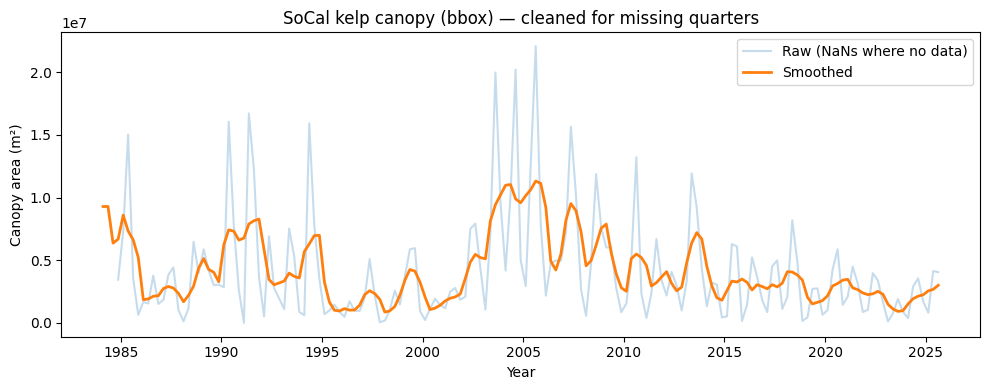

In [6]:
#5 load + clean kelp timeseries (from CSV) + plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_kelp = pd.read_csv("../data/kelp_timeseries_bbox.csv", index_col=0, parse_dates=True).sort_index()

# If coverage is 0, kelp_area=0 is "no data", not real zero kelp
df_kelp.loc[df_kelp["coverage"] == 0, "kelp_area"] = np.nan
# Recompute smooth after fixing missing data
df_kelp["kelp_smooth"] = df_kelp["kelp_area"].rolling(4, center=True, min_periods=1).mean()

print(df_kelp[["kelp_area","coverage","kelp_smooth"]].head(10))

plt.figure(figsize=(10,4))
plt.plot(df_kelp.index, df_kelp["kelp_area"], alpha=0.25, label="Raw (NaNs where no data)")
plt.plot(df_kelp.index, df_kelp["kelp_smooth"], linewidth=2, label="Smoothed")
plt.title("SoCal kelp canopy (bbox) — cleaned for missing quarters")
plt.xlabel("Year")
plt.ylabel("Canopy area (m²)")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
#6 “official analysis table” (kelp + SST)
import pandas as pd
import numpy as np

# 0) Ensure SST exists (load from disk if not in memory)
try:
    sst_quarterly
except NameError:
    sst_path = "../data/sst_quarterly_bbox.csv"
    sst_quarterly = pd.read_csv(sst_path, index_col=0, parse_dates=True).iloc[:, 0]
    sst_quarterly.name = "sst"
    print("Loaded SST quarterly from:", sst_path)

# 1) quarter-align kelp (IMPORTANT: coverage should be max, not mean)
df_kelp_q = df_kelp[["kelp_area","kelp_smooth","coverage"]].copy()
df_kelp_q["q"] = df_kelp_q.index.to_period("Q")

df_kelp_q = df_kelp_q.groupby("q").agg({
    "kelp_area": "mean",
    "kelp_smooth": "mean",
    "coverage": "max"
})

df_kelp_q.index = df_kelp_q.index.to_timestamp("Q")

# 2) quarter-align SST
sst_q = sst_quarterly.copy()
if isinstance(sst_q, pd.DataFrame):
    sst_q = sst_q.iloc[:, 0]

sst_q.index = pd.to_datetime(sst_q.index)
sst_q = sst_q.groupby(sst_q.index.to_period("Q")).mean()
sst_q.index = sst_q.index.to_timestamp("Q")

df_sst = sst_q.to_frame("sst")
df_sst["sst_anom"] = df_sst["sst"] - df_sst.groupby(df_sst.index.quarter)["sst"].transform("mean")

# 3) merge
df_combo = df_kelp_q.join(df_sst, how="inner")

# Optional: drop quarters with low coverage (keeps only reliable observations)
cov_thresh = 0.8 * df_combo["coverage"].max()
df_combo = df_combo[df_combo["coverage"] >= cov_thresh]

print("df_combo rows:", len(df_combo))
print("range:", df_combo.index.min(), "to", df_combo.index.max())
print(df_combo.head())

out_csv = "../data/analysis_table_kelp_sst_bbox.csv"
df_combo.to_csv(out_csv)
print("Saved:", out_csv)


df_combo rows: 161
range: 1984-06-30 00:00:00 to 2025-09-30 00:00:00
            kelp_area   kelp_smooth  coverage        sst  sst_anom
1984-06-30  9290381.0  9.290381e+06    112026  14.629942  0.362289
1984-12-31  3450350.0  6.685867e+06    114799  15.600410 -0.399970
1985-03-31  7316869.0  8.600573e+06    114812  13.326952 -0.515503
1985-09-30  3561541.0  6.637612e+06    113278  17.361467  0.043327
1985-12-31   637540.0  5.228020e+06    112500  15.520946 -0.479434
Saved: ../data/analysis_table_kelp_sst_bbox.csv


In [12]:
#7 save SST quarterly (one-time)

import xarray as xr
import pandas as pd
import numpy as np
from glob import glob

paths = sorted(glob("../data/oisst_socal_*.nc"))
print("Found OISST files:", len(paths))
print("First/last:", paths[0], "|", paths[-1])

ds_sst = xr.open_mfdataset(paths, combine="by_coords")

# pick SST variable robustly
if "sst" in ds_sst.data_vars:
    da = ds_sst["sst"]
else:
    da = ds_sst[list(ds_sst.data_vars)[0]]
    print("Using variable:", da.name)

print("SST dims:", da.dims)

# ---- FIX: collapse depth dimension if present ----
if "zlev" in da.dims:
    # surface level (usually only one). pick first to remove MultiIndex issues
    da = da.isel(zlev=0)
    print("Selected zlev=0; new dims:", da.dims)

# spatial dims
spatial_dims = [d for d in da.dims if d.lower() in ["lat", "latitude", "lon", "longitude"]]
print("Spatial dims:", spatial_dims)

# average over space -> 1D daily series
sst_daily = da.mean(dim=spatial_dims, skipna=True)

# convert to pandas Series (index should now be time only)
sst_daily_series = sst_daily.to_series()
sst_daily_series.index = pd.to_datetime(sst_daily_series.index)
sst_daily_series = sst_daily_series.sort_index()
sst_daily_series.name = "sst"

print("Daily SST:", len(sst_daily_series), "days | range:", sst_daily_series.index.min(), "→", sst_daily_series.index.max())

# quarterly mean
sst_quarterly = sst_daily_series.resample("Q").mean()
sst_quarterly.name = "sst"

print("Quarterly SST:", len(sst_quarterly), "quarters | range:", sst_quarterly.index.min(), "→", sst_quarterly.index.max())
print(sst_quarterly.head())

sst_out = "../data/sst_quarterly_bbox.csv"
sst_quarterly.to_csv(sst_out)
print("Saved:", sst_out)


Found OISST files: 12
First/last: ../data/oisst_socal_1984-01-01_1988-12-31.nc | ../data/oisst_socal_2024-01-01_2025-12-31.nc
SST dims: ('time', 'zlev', 'latitude', 'longitude')
Selected zlev=0; new dims: ('time', 'latitude', 'longitude')
Spatial dims: ['latitude', 'longitude']
Daily SST: 15335 days | range: 1984-01-01 12:00:00 → 2025-12-31 12:00:00
Quarterly SST: 168 quarters | range: 1984-03-31 00:00:00 → 2025-12-31 00:00:00
time
1984-03-31    14.817052
1984-06-30    14.629942
1984-09-30    19.346985
1984-12-31    15.600410
1985-03-31    13.326952
Freq: QE-DEC, Name: sst, dtype: float32
Saved: ../data/sst_quarterly_bbox.csv


/var/folders/61/3wm_gk5j5jvd7cv3mv31_8940000gn/T/ipykernel_5919/2879838151.py:45: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  sst_quarterly = sst_daily_series.resample("Q").mean()


Events found: 2


,peak_time,peak_val,collapse_start,collapse_end,duration_q,collapse_level,trough_time,trough_val,drop_frac_realized
0,1985-03-31,8600573.00,1986-03-31,1988-09-30,11,3440229.2,1988-03-31,1687432.50,0.803800
1,1989-03-31,5135765.25,1995-06-30,1996-12-31,6,2054306.1,1995-12-31,952464.25,0.814543


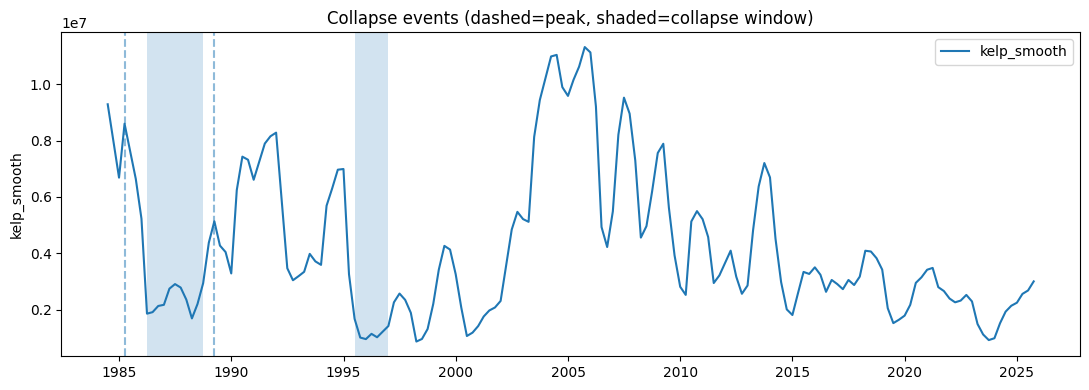

In [27]:
#8 collapse event detection (kelp only)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_collapse_events(
    s,
    drop_frac=0.6,        # collapse = >=60% drop from a peak
    search_horizon=24,    # must occur within 24 quarters (~6 years) after peak
    min_duration=4,       # must stay collapsed for >=4 quarters (~1 year)
):
    s = s.dropna().astype(float)
    x = s.values
    t = s.index

    # simple local peaks
    is_peak = np.zeros(len(s), dtype=bool)
    is_peak[1:-1] = (x[1:-1] > x[:-2]) & (x[1:-1] >= x[2:])
    peaks = np.where(is_peak)[0]

    events = []
    used_until = -1

    for p in peaks:
        if p <= used_until:
            continue

        peak_val = x[p]
        peak_time = t[p]
        collapse_level = (1 - drop_frac) * peak_val

        end_search = min(len(s), p + search_horizon + 1)
        forward = x[p+1:end_search]
        if forward.size == 0:
            continue

        hits = np.where(forward <= collapse_level)[0]
        if hits.size == 0:
            continue

        start_c = p + 1 + hits[0]

        # sustained time below collapse_level
        end_c = start_c
        while end_c < len(s) and x[end_c] <= collapse_level:
            end_c += 1

        duration = end_c - start_c
        if duration < min_duration:
            continue

        trough_idx = start_c + int(np.argmin(x[start_c:end_c]))
        trough_val = x[trough_idx]

        events.append({
            "peak_time": peak_time,
            "peak_val": peak_val,
            "collapse_start": t[start_c],
            "collapse_end": t[end_c - 1],
            "duration_q": duration,
            "collapse_level": collapse_level,
            "trough_time": t[trough_idx],
            "trough_val": trough_val,
            "drop_frac_realized": (peak_val - trough_val) / peak_val
        })

        used_until = end_c - 1

    return pd.DataFrame(events).sort_values("collapse_start").reset_index(drop=True)

events = find_collapse_events(df_kelp_q_f["kelp_smooth"], drop_frac=0.6, search_horizon=24, min_duration=4)

print("Events found:", len(events))
display(events.head(10))

plt.figure(figsize=(11,4))
plt.plot(df_kelp_q_f.index, df_kelp_q_f["kelp_smooth"], label="kelp_smooth")
for _, e in events.iterrows():
    plt.axvline(e["peak_time"], linestyle="--", alpha=0.5)
    plt.axvspan(e["collapse_start"], e["collapse_end"], alpha=0.2)
plt.title("Collapse events (dashed=peak, shaded=collapse window)")
plt.ylabel("kelp_smooth")
plt.legend()
plt.tight_layout()
plt.show()


             kelp_smooth  ews_var  ews_ar1
q                                         
1984-06-30  9.290381e+06      NaN      NaN
1984-12-31  6.685867e+06      NaN      NaN
1985-03-31  8.600573e+06      NaN      NaN
1985-09-30  6.637612e+06      NaN      NaN
1985-12-31  5.228020e+06      NaN      NaN


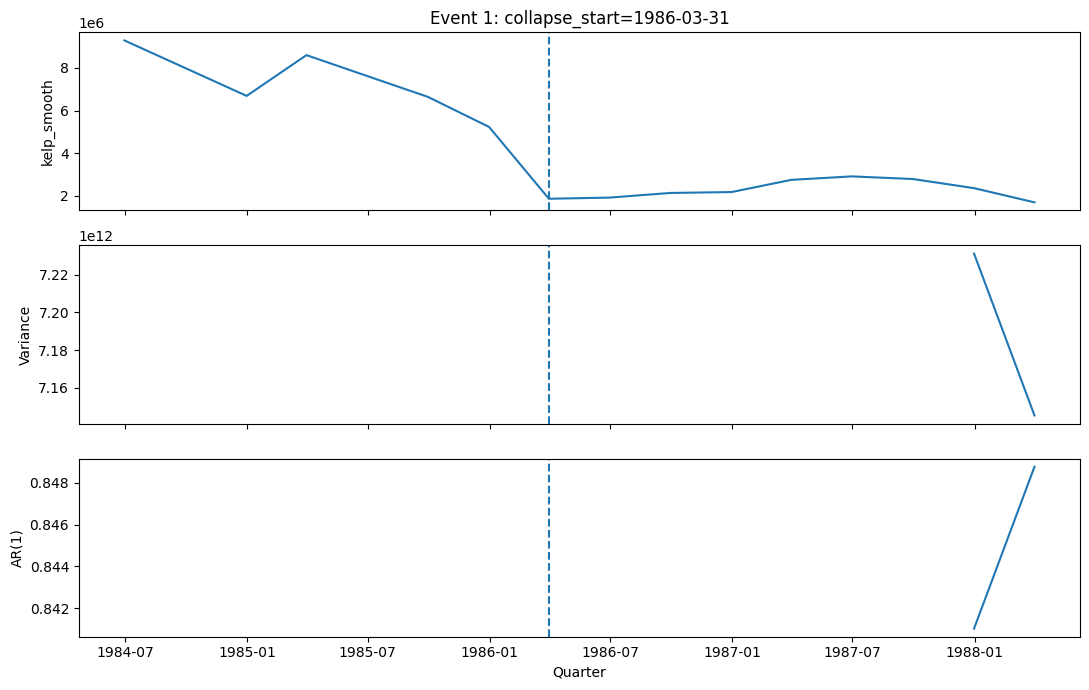

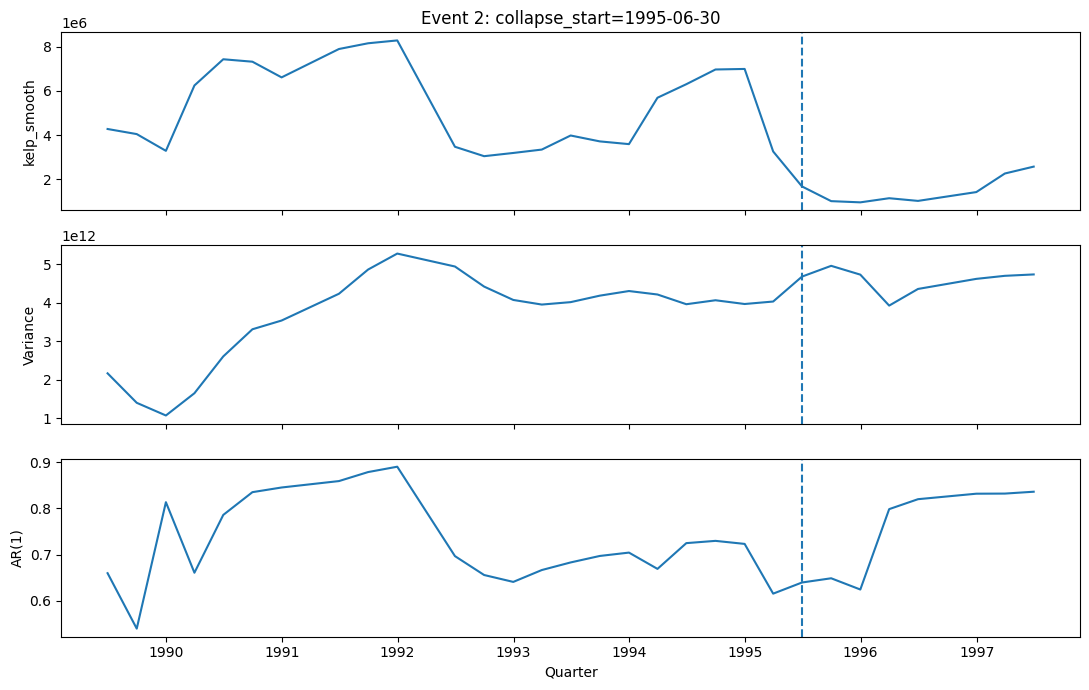

In [10]:
#9 early warning signals (variance + AR1) before collapses

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ar1(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 3:
        return np.nan
    x0, x1 = x[:-1], x[1:]
    if np.std(x0) == 0 or np.std(x1) == 0:
        return np.nan
    return np.corrcoef(x0, x1)[0, 1]

def rolling_ews(s, window=16, min_valid_frac=0.8):
    """
    window in quarters (16 = 4 years). Uses trailing window.
    Returns df with ews_var and ews_ar1 aligned to the right edge of the window.
    """
    s = s.astype(float)
    out = pd.DataFrame(index=s.index, columns=["ews_var", "ews_ar1"], dtype=float)

    min_n = int(np.ceil(window * min_valid_frac))

    for i in range(len(s)):
        w = s.iloc[max(0, i - window + 1): i + 1]
        x = w.values
        x = x[np.isfinite(x)]
        if len(x) < min_n:
            continue

        # EWS often computed on anomalies (demean within window)
        x = x - np.mean(x)

        out.iloc[i, 0] = np.var(x, ddof=1) if len(x) > 1 else np.nan
        out.iloc[i, 1] = ar1(x)

    return out

# compute EWS on filtered quarterly kelp series
ews = rolling_ews(df_kelp_q_f["kelp_smooth"], window=16, min_valid_frac=0.8)
df_ews = df_kelp_q_f.join(ews)

print(df_ews[["kelp_smooth", "ews_var", "ews_ar1"]].head())

# plot per event: pre-window view
PRE_Q = 24   # quarters before collapse start (~6 years)
POST_Q = 8   # quarters after (~2 years)

for k, e in events.iterrows():
    t0 = e["collapse_start"]
    t_start = t0 - pd.offsets.QuarterEnd(PRE_Q)
    t_end   = t0 + pd.offsets.QuarterEnd(POST_Q)

    sub = df_ews.loc[(df_ews.index >= t_start) & (df_ews.index <= t_end)].copy()
    if sub.empty:
        continue

    fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

    axes[0].plot(sub.index, sub["kelp_smooth"])
    axes[0].axvline(t0, linestyle="--")
    axes[0].set_ylabel("kelp_smooth")
    axes[0].set_title(f"Event {k+1}: collapse_start={t0.date()}")

    axes[1].plot(sub.index, sub["ews_var"])
    axes[1].axvline(t0, linestyle="--")
    axes[1].set_ylabel("Variance")

    axes[2].plot(sub.index, sub["ews_ar1"])
    axes[2].axvline(t0, linestyle="--")
    axes[2].set_ylabel("AR(1)")
    axes[2].set_xlabel("Quarter")

    plt.tight_layout()
    plt.show()


In [11]:
#10 quantify pre-collapse EWS trends (variance + AR1)

import numpy as np
import pandas as pd

def slope(y):
    y = np.asarray(y, dtype=float)
    m = np.isfinite(y)
    y = y[m]
    if len(y) < 5:
        return np.nan
    x = np.arange(len(y), dtype=float)
    # linear slope
    return np.polyfit(x, y, 1)[0]

PRE_Q = 24  # quarters to look back before collapse_start

rows = []
for k, e in events.iterrows():
    t0 = e["collapse_start"]
    pre = df_ews.loc[(df_ews.index < t0) & (df_ews.index >= (t0 - pd.offsets.QuarterEnd(PRE_Q)))]

    rows.append({
        "event": k + 1,
        "collapse_start": t0,
        "n_pre": int(pre["kelp_smooth"].notna().sum()),
        "var_slope": slope(pre["ews_var"]),
        "ar1_slope": slope(pre["ews_ar1"]),
        "var_pre_end": pre["ews_var"].iloc[-1] if len(pre) else np.nan,
        "ar1_pre_end": pre["ews_ar1"].iloc[-1] if len(pre) else np.nan,
    })

trend_table = pd.DataFrame(rows)
display(trend_table)


,event,collapse_start,n_pre,var_slope,ar1_slope,var_pre_end,ar1_pre_end
0,1,1986-03-31,5,NaN,NaN,NaN,NaN
1,2,1995-06-30,22,1.134675e+11,-0.002981,4.027071e+12,0.615412


Events found: 2


,peak_time,peak_val,collapse_start,collapse_end,duration_q,collapse_level,trough_time,trough_val,drop_frac_realized
0,1985-03-31,8600573.00,1986-03-31,1988-09-30,11,3440229.2,1988-03-31,1687432.50,0.803800
1,1989-03-31,5135765.25,1995-06-30,1996-12-31,6,2054306.1,1995-12-31,952464.25,0.814543


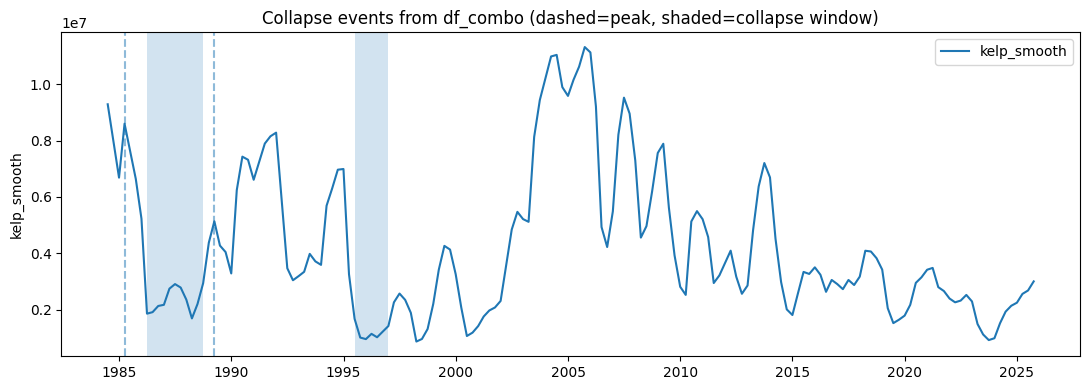

In [14]:
#11 collapse event detection (using df_combo)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_collapse_events(
    s,
    drop_frac=0.6,        # collapse = >=60% drop from a peak
    search_horizon=24,    # must occur within 24 quarters (~6 years) after peak
    min_duration=4,       # must stay collapsed for >=4 quarters (~1 year)
):
    s = s.dropna().astype(float)
    x = s.values
    t = s.index

    # simple local peaks
    is_peak = np.zeros(len(s), dtype=bool)
    is_peak[1:-1] = (x[1:-1] > x[:-2]) & (x[1:-1] >= x[2:])
    peaks = np.where(is_peak)[0]

    events = []
    used_until = -1

    for p in peaks:
        if p <= used_until:
            continue

        peak_val = x[p]
        peak_time = t[p]
        collapse_level = (1 - drop_frac) * peak_val

        end_search = min(len(s), p + search_horizon + 1)
        forward = x[p+1:end_search]
        if forward.size == 0:
            continue

        hits = np.where(forward <= collapse_level)[0]
        if hits.size == 0:
            continue

        start_c = p + 1 + hits[0]

        end_c = start_c
        while end_c < len(s) and x[end_c] <= collapse_level:
            end_c += 1

        duration = end_c - start_c
        if duration < min_duration:
            continue

        trough_idx = start_c + int(np.argmin(x[start_c:end_c]))
        trough_val = x[trough_idx]

        events_combo = {
            "peak_time": peak_time,
            "peak_val": peak_val,
            "collapse_start": t[start_c],
            "collapse_end": t[end_c - 1],
            "duration_q": duration,
            "collapse_level": collapse_level,
            "trough_time": t[trough_idx],
            "trough_val": trough_val,
            "drop_frac_realized": (peak_val - trough_val) / peak_val
        }
        events.append(events_combo)

        used_until = end_c - 1

    return pd.DataFrame(events).sort_values("collapse_start").reset_index(drop=True)

events = find_collapse_events(df_combo["kelp_smooth"], drop_frac=0.6, search_horizon=24, min_duration=4)

print("Events found:", len(events))
display(events.head(10))

# plot kelp + collapse windows
plt.figure(figsize=(11,4))
plt.plot(df_combo.index, df_combo["kelp_smooth"], label="kelp_smooth")
for _, e in events.iterrows():
    plt.axvline(e["peak_time"], linestyle="--", alpha=0.5)
    plt.axvspan(e["collapse_start"], e["collapse_end"], alpha=0.2)
plt.title("Collapse events from df_combo (dashed=peak, shaded=collapse window)")
plt.ylabel("kelp_smooth")
plt.legend()
plt.tight_layout()
plt.show()


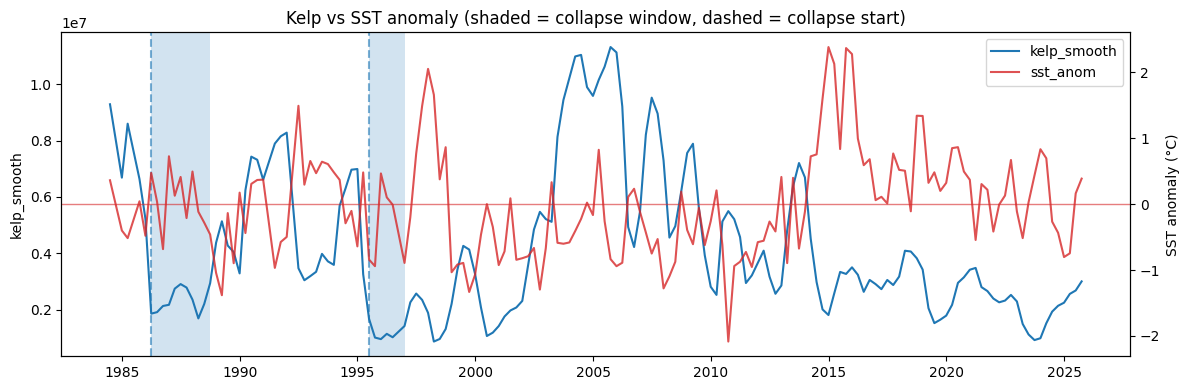

In [17]:
#12 plot kelp + SST anomaly with collapse windows

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,4))

# kelp on left axis (default color)
ax1.plot(df_combo.index, df_combo["kelp_smooth"], label="kelp_smooth")
ax1.set_ylabel("kelp_smooth")

# SST anomaly on right axis (force different color)
ax2 = ax1.twinx()
ax2.plot(df_combo.index, df_combo["sst_anom"], color="tab:red", alpha=0.8, label="sst_anom")
ax2.axhline(0, color="tab:red", linewidth=1, alpha=0.6)
ax2.set_ylabel("SST anomaly (°C)")

# collapse windows
for _, e in events.iterrows():
    ax1.axvspan(e["collapse_start"], e["collapse_end"], alpha=0.2)
    ax1.axvline(e["collapse_start"], linestyle="--", alpha=0.6)

ax1.set_title("Kelp vs SST anomaly (shaded = collapse window, dashed = collapse start)")

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig.tight_layout()
plt.show()


,lag_q,n,pearson_r,pearson_p,spearman_r,spearman_p
0,0,160,-0.174750,0.027096,-0.160538,0.042568
1,1,160,0.074518,0.349016,0.074353,0.350091
2,2,159,0.076754,0.336241,0.091500,0.251348
3,3,158,0.168837,0.033952,0.126952,0.111941
4,4,157,0.083502,0.298462,0.056562,0.481670
5,5,156,-0.087301,0.278503,-0.145144,0.070629
6,6,155,-0.071523,0.376494,-0.132835,0.099413
7,7,154,-0.018307,0.821703,-0.041925,0.605672
8,8,153,-0.078188,0.336716,-0.043427,0.594024
9,9,152,-0.064218,0.431863,-0.050243,0.538745


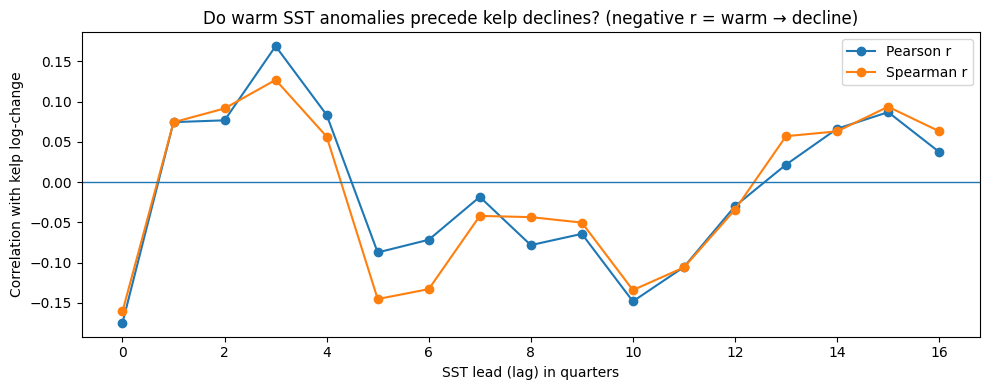

In [19]:
#15 lagged correlation: kelp decline rate vs SST anomaly

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

df = df_combo.copy()

# response: quarterly log-change (≈ growth rate)
df["kelp_log"] = np.log(df["kelp_smooth"])
df["kelp_dlog"] = df["kelp_log"].diff()   # negative = decline

lags = list(range(0, 17))  # 0..16 quarters (0..4 years)
rows = []

for L in lags:
    x = df["sst_anom"].shift(L)
    y = df["kelp_dlog"]

    m = x.notna() & y.notna()
    if m.sum() < 20:
        rows.append({"lag_q": L, "n": int(m.sum()), "pearson_r": np.nan, "pearson_p": np.nan,
                     "spearman_r": np.nan, "spearman_p": np.nan})
        continue

    pr, pp = pearsonr(x[m].values, y[m].values)
    sr, sp = spearmanr(x[m].values, y[m].values)

    rows.append({"lag_q": L, "n": int(m.sum()),
                 "pearson_r": pr, "pearson_p": pp,
                 "spearman_r": sr, "spearman_p": sp})

corr_table = pd.DataFrame(rows)
display(corr_table)

plt.figure(figsize=(10,4))
plt.plot(corr_table["lag_q"], corr_table["pearson_r"], marker="o", label="Pearson r")
plt.plot(corr_table["lag_q"], corr_table["spearman_r"], marker="o", label="Spearman r")
plt.axhline(0, linewidth=1)
plt.xlabel("SST lead (lag) in quarters")
plt.ylabel("Correlation with kelp log-change")
plt.title("Do warm SST anomalies precede kelp declines? (negative r = warm → decline)")
plt.legend()
plt.tight_layout()
plt.show()


Window: 2007-12-31 → 2017-12-31 | rows: 41


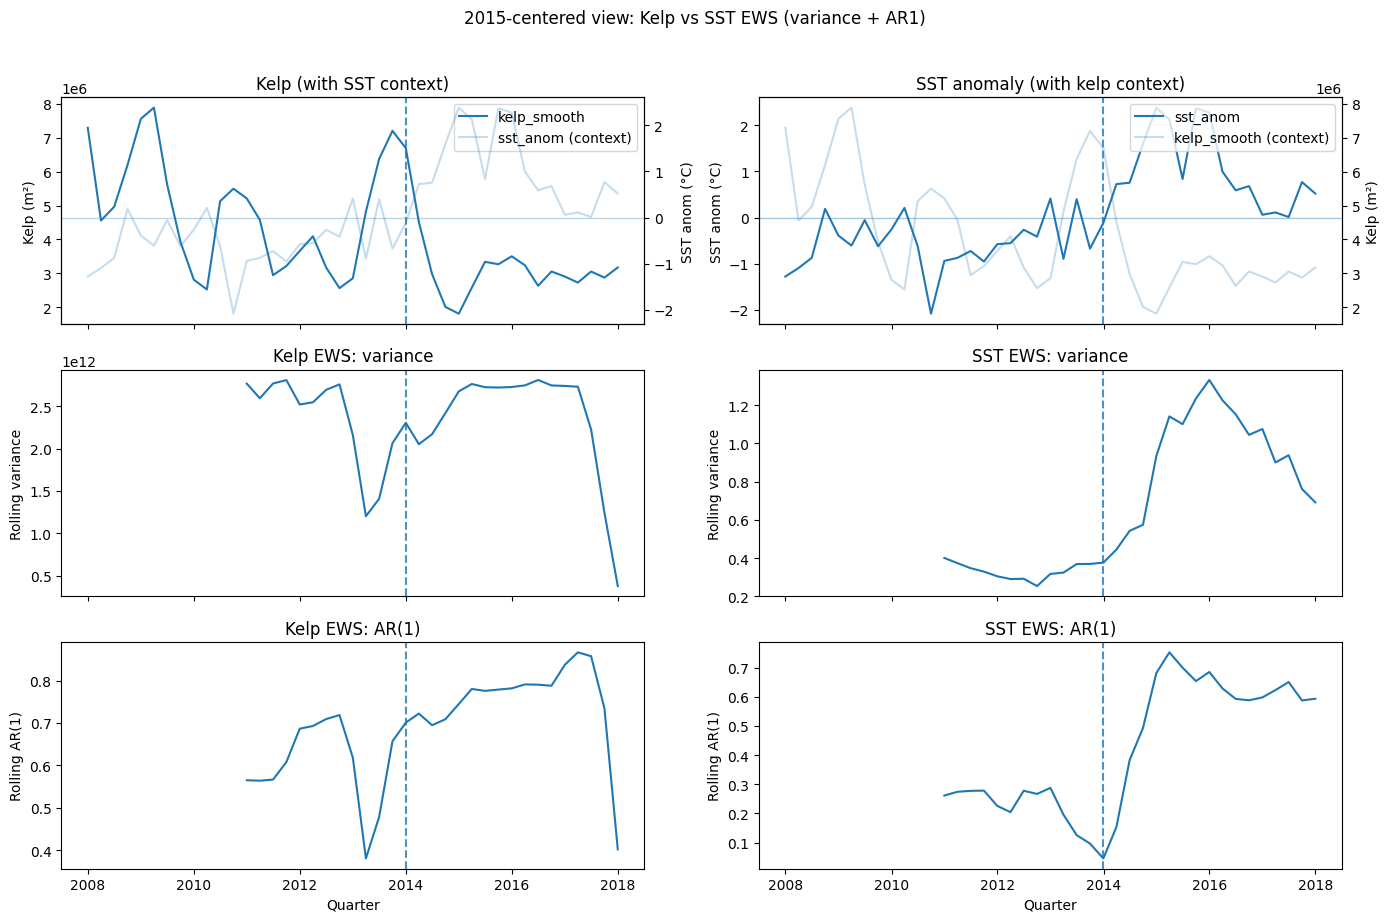

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- load if needed ---
try:
    df_combo
except NameError:
    df_combo = pd.read_csv("../data/analysis_table_kelp_sst_bbox.csv", index_col=0, parse_dates=True)

# --- helpers ---
def _ar1(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 3:
        return np.nan
    x0, x1 = x[:-1], x[1:]
    if np.std(x0) == 0 or np.std(x1) == 0:
        return np.nan
    return np.corrcoef(x0, x1)[0, 1]

def rolling_ews(s, window=16, min_valid_frac=0.8):
    s = s.astype(float)
    out = pd.DataFrame(index=s.index, columns=["ews_var", "ews_ar1"], dtype=float)
    min_n = int(np.ceil(window * min_valid_frac))
    for i in range(len(s)):
        w = s.iloc[max(0, i-window+1):i+1]
        x = w.values
        x = x[np.isfinite(x)]
        if len(x) < min_n:
            continue
        x = x - np.mean(x)
        out.iloc[i, 0] = np.var(x, ddof=1) if len(x) > 1 else np.nan
        out.iloc[i, 1] = _ar1(x)
    return out

# --- settings for the "2015 dip" view ---
CENTER = pd.Timestamp("2013-12-31")  # quarter end near mid-2015
PRE_Q = 24   # 6 years before
POST_Q = 16  # 4 years after

t_start = CENTER - pd.offsets.QuarterEnd(PRE_Q)
t_end   = CENTER + pd.offsets.QuarterEnd(POST_Q)

sub = df_combo.loc[(df_combo.index >= t_start) & (df_combo.index <= t_end)].copy()

# --- EWS for BOTH series ---
ews_kelp = rolling_ews(sub["kelp_smooth"], window=16, min_valid_frac=0.8).add_prefix("kelp_")
ews_sst  = rolling_ews(sub["sst_anom"],   window=16, min_valid_frac=0.8).add_prefix("sst_")

sub = sub.join([ews_kelp, ews_sst])

print("Window:", sub.index.min().date(), "→", sub.index.max().date(), "| rows:", len(sub))

# --- plot: 3 rows x 2 cols (kelp vs sst) ---
fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)

# Row 1: raw series (plus faint context overlay)
# (1,1) kelp
axes[0, 0].plot(sub.index, sub["kelp_smooth"], label="kelp_smooth")
ax0b = axes[0, 0].twinx()
ax0b.plot(sub.index, sub["sst_anom"], alpha=0.25, label="sst_anom (context)")
ax0b.axhline(0, linewidth=1, alpha=0.3)
axes[0, 0].axvline(CENTER, linestyle="--", alpha=0.8)
axes[0, 0].set_title("Kelp (with SST context)")
axes[0, 0].set_ylabel("Kelp (m²)")
ax0b.set_ylabel("SST anom (°C)")

# merged legend for left top
l1, lab1 = axes[0, 0].get_legend_handles_labels()
l2, lab2 = ax0b.get_legend_handles_labels()
axes[0, 0].legend(l1 + l2, lab1 + lab2, loc="upper right")

# (1,2) sst
axes[0, 1].plot(sub.index, sub["sst_anom"], label="sst_anom")
axes[0, 1].axhline(0, linewidth=1, alpha=0.4)
ax1b = axes[0, 1].twinx()
ax1b.plot(sub.index, sub["kelp_smooth"], alpha=0.25, label="kelp_smooth (context)")
axes[0, 1].axvline(CENTER, linestyle="--", alpha=0.8)
axes[0, 1].set_title("SST anomaly (with kelp context)")
axes[0, 1].set_ylabel("SST anom (°C)")
ax1b.set_ylabel("Kelp (m²)")

# merged legend for right top
l1, lab1 = axes[0, 1].get_legend_handles_labels()
l2, lab2 = ax1b.get_legend_handles_labels()
axes[0, 1].legend(l1 + l2, lab1 + lab2, loc="upper right")

# Row 2: rolling variance
axes[1, 0].plot(sub.index, sub["kelp_ews_var"])
axes[1, 0].axvline(CENTER, linestyle="--", alpha=0.8)
axes[1, 0].set_ylabel("Rolling variance")
axes[1, 0].set_title("Kelp EWS: variance")

axes[1, 1].plot(sub.index, sub["sst_ews_var"])
axes[1, 1].axvline(CENTER, linestyle="--", alpha=0.8)
axes[1, 1].set_ylabel("Rolling variance")
axes[1, 1].set_title("SST EWS: variance")

# Row 3: AR(1)
axes[2, 0].plot(sub.index, sub["kelp_ews_ar1"])
axes[2, 0].axvline(CENTER, linestyle="--", alpha=0.8)
axes[2, 0].set_ylabel("Rolling AR(1)")
axes[2, 0].set_xlabel("Quarter")
axes[2, 0].set_title("Kelp EWS: AR(1)")

axes[2, 1].plot(sub.index, sub["sst_ews_ar1"])
axes[2, 1].axvline(CENTER, linestyle="--", alpha=0.8)
axes[2, 1].set_ylabel("Rolling AR(1)")
axes[2, 1].set_xlabel("Quarter")
axes[2, 1].set_title("SST EWS: AR(1)")

fig.suptitle("2015-centered view: Kelp vs SST EWS (variance + AR1)", y=1.02)
fig.tight_layout()
plt.show()


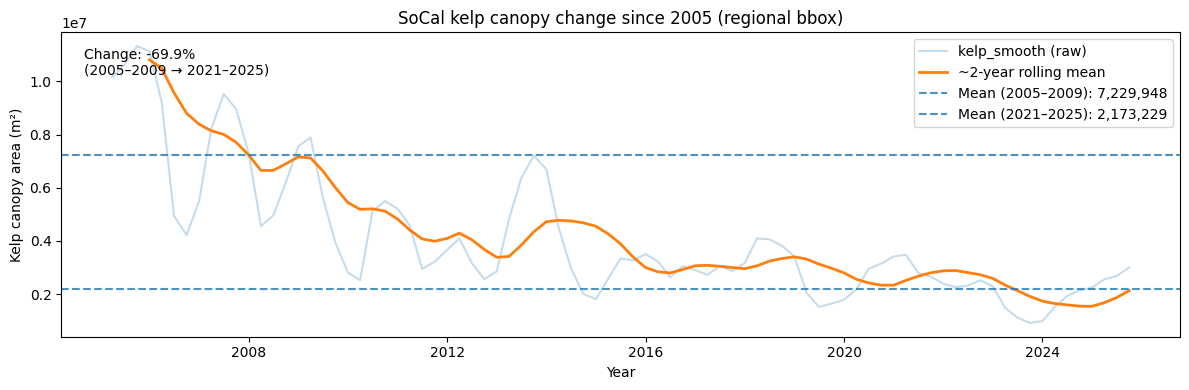

Mean 2005–2009: 7229948.25 | Mean 2021–2025: 2173229.49122807 | % change: -69.94128566234107


In [26]:
#15 stark long-term decline plot (start at 2005)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load if needed
try:
    df_combo
except NameError:
    df_combo = pd.read_csv("../data/analysis_table_kelp_sst_bbox.csv", index_col=0, parse_dates=True)

# ---- START AT 2005 ----
s = df_combo.loc[df_combo.index >= "2005-01-01", "kelp_smooth"].astype(float).copy()

# rolling mean for a clean story
roll = s.rolling(8, min_periods=4).mean()  # ~2-year smoothing (quarterly data)

# define "early" and "recent" windows (relative to 2005 start)
early_years = (2005, 2009)   # first 5-ish years after 2005
recent_years = (2021, 2025)  # most recent ~5 years

early = s[(s.index.year >= early_years[0]) & (s.index.year <= early_years[1])]
recent = s[(s.index.year >= recent_years[0]) & (s.index.year <= recent_years[1])]

early_mean = float(np.nanmean(early))
recent_mean = float(np.nanmean(recent))
pct_change = 100 * (recent_mean - early_mean) / early_mean

fig, ax = plt.subplots(figsize=(12,4))

ax.plot(s.index, s, alpha=0.25, label="kelp_smooth (raw)")
ax.plot(roll.index, roll, linewidth=2, label="~2-year rolling mean")

# horizontal reference lines
ax.axhline(early_mean, linestyle="--", alpha=0.8,
           label=f"Mean ({early_years[0]}–{early_years[1]}): {early_mean:,.0f}")
ax.axhline(recent_mean, linestyle="--", alpha=0.8,
           label=f"Mean ({recent_years[0]}–{recent_years[1]}): {recent_mean:,.0f}")

# annotate percent change
txt = f"Change: {pct_change:.1f}%\n({early_years[0]}–{early_years[1]} → {recent_years[0]}–{recent_years[1]})"
ax.text(0.02, 0.95, txt, transform=ax.transAxes, va="top")

ax.set_title("SoCal kelp canopy change since 2005 (regional bbox)")
ax.set_xlabel("Year")
ax.set_ylabel("Kelp canopy area (m²)")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

print("Mean 2005–2009:", early_mean, "| Mean 2021–2025:", recent_mean, "| % change:", pct_change)
